In [ ]:
# ۱. تعریف متن ضوابط معماری دبی/آمریکا به همراه سطح اشغال (Lot Coverage)
zoning_text = """
Zoning Regulation Guidelines - District 4B:
- Maximum Floor Area Ratio (FAR): 3.5
- Maximum Height Limit: 45 meters
- Maximum Lot Coverage: 60%
- Minimum Front Setback: 5 meters
"""

# ۲. تبدیل متن به خطوط مجزا برای بررسی تک‌تک جملات
lines = zoning_text.split('\n')

# ۳. بررسی خط به خط متن توسط پایتون و استخراج ضوابط کلیدی
for line in lines:
    if "FAR" in line:
        print("Found FAR Regulation ->", line.strip())

    if "Height Limit" in line:
        print("Found Height Regulation ->", line.strip())

    if "Lot Coverage" in line:
        print("Found Coverage Regulation ->", line.strip())

Found FAR Regulation -> - Maximum Floor Area Ratio (FAR): 3.5
Found Height Regulation -> - Maximum Height Limit: 45 meters
Found Coverage Regulation -> - Maximum Lot Coverage: 60%


In [ ]:
import io
import pandas as pd

# ۱. شبیه‌سازی یک فایل اکسل/CSV از ضوابط ۵ زمین مختلف در منطقه دبی
csv_data = """Plot_ID,Zone,Max_FAR,Max_Height
P-101,Residential,2.5,15
P-102,Commercial,4.0,50
P-103,Residential,1.8,12
P-104,Mixed-Use,3.5,35
P-105,Commercial,5.5,70
"""

# ۲. خواندن داده‌ها توسط کتابخانه قدرتمند Pandas
df = pd.read_csv(io.StringIO(csv_data))

# ۳. فیلتر کردن زمین‌هایی که حداکثر ارتفاع مجاز آن‌ها بالای ۳۰ متر است
high_rise_plots = df[df['Max_Height'] > 30]

# ۴. چاپ کردن خروجی دیتای فیلتر شده
print(high_rise_plots)

  Plot_ID        Zone  Max_FAR  Max_Height
1   P-102  Commercial      4.0          50
3   P-104   Mixed-Use      3.5          35
4   P-105  Commercial      5.5          70


In [ ]:
!pip install langchain-community


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
!pip install langchain-core langchain-community

In [ ]:
!pip install google-generativeai

In [ ]:
!pip install google-genai

In [19]:
import requests
import json

# ۱. استفاده از کلید API جدید و معتبر کیمیا از سایت اوپن‌روتر
OPENROUTER_API_KEY = "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"
BASE_URL = "https://openrouter.ai/api/v1/chat/completions"

# ۲. متن ضوابط منطقه دبی
complex_zoning = """
Dubai Development Authority - Zone Z-1:
The maximum allowable Floor Area Ratio (FAR) for commercial development shall be limited to 4.5.
However, if the plot is adjacent to a main highway, a bonus FAR of 0.5 may be granted.
Residential buildings are restricted to a maximum FAR of 2.8 and a height limit of 24 meters.
"""

prompt = f"""
You are an expert international zoning agent.
Analyze this text and tell me: What is the TOTAL maximum FAR for a COMMERCIAL building next to a highway?
(Calculate base FAR + bonus if applicable).
Text: {complex_zoning}
Answer in just one short and direct sentence.
"""

# ۳. تنظیمات هدر استاندارد
headers = {
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type": "application/json",
    "HTTP-Referer": "https://google.colab",
    "X-Title": "Algorithmic Architecture Agent"
}

# ۴. استفاده از مدل فوق‌پایدار GPT-4o با محدودیت دقیق توکن
payload = {
    "model": "openai/gpt-4o",
    "messages": [{"role": "user", "content": prompt}],
    "max_tokens": 80,  # پاسخ کوتاه، مصرف توکن بسیار پایین
    "temperature": 0.1
}

# ۵. شلیک نهایی به سرور و دریافت پاسخ
try:
    response = requests.post(BASE_URL, headers=headers, json=payload)
    result = response.json()

    if 'choices' in result:
        print("🤖 AI Agent Response (GPT-4o via OpenRouter):")
        print(result['choices'][0]['message']['content'])
    else:
        print("⚠️ Check Server Response:")
        print(json.dumps(result, indent=2))
except Exception as e:
    print(f"⚠️ Connection Error: {e}")

🤖 AI Agent Response (GPT-4o via OpenRouter):
The total maximum FAR for a commercial building next to a highway in Zone Z-1 is 5.0.


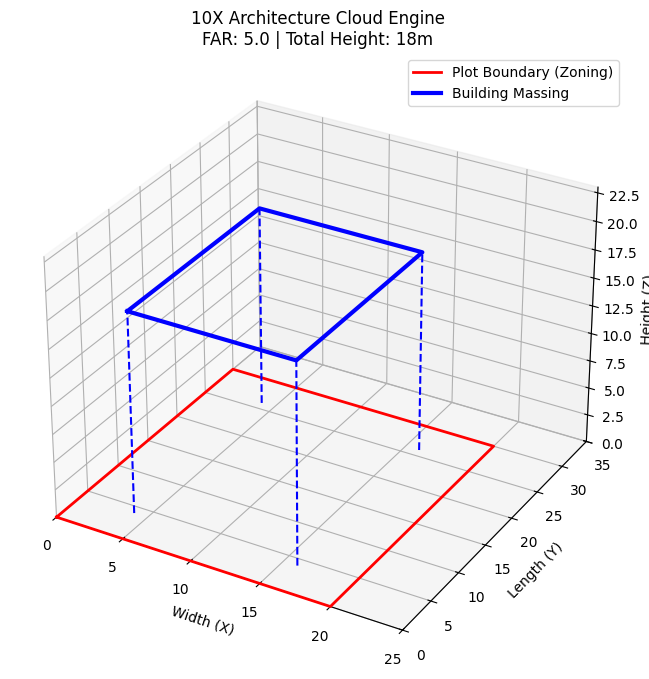

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ۱. ورودی‌های الگوریتم معماری
plot_width = 20       # عرض زمین (متر)
plot_length = 30      # طول زمین (متر)
setback = 4           # عقب‌نشینی ضوابط از هر طرف (متر)
far = 5.0             # تراکمی که در فاز اول از هوش مصنوعی گرفتیم
floors = 6            # تعداد طبقات مد نظر
floor_height = 3      # ارتفاع هر طبقه (متر)

# ۲. محاسبات هندسی حجم ساختمان
bldg_width = plot_width - (2 * setback)     # عرض ساختمان بعد از عقب‌نشینی
bldg_length = plot_length - (2 * setback)   # طول ساختمان بعد از عقب‌نشینی
bldg_height = floors * floor_height         # ارتفاع کل برج

# ۳. شبیه‌سازی و رسم فضای سه‌بعدی
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# رسم خطوط قرمز مرز زمین (کف)
x_plot = [0, plot_width, plot_width, 0, 0]
y_plot = [0, 0, plot_length, plot_length, 0]
ax.plot(x_plot, y_plot, 0, color='red', linewidth=2, label='Plot Boundary (Zoning)')

# رسم خطوط آبی سقف ساختمان در ارتفاع نهایی
ax.plot([setback, setback+bldg_width, setback+bldg_width, setback, setback],
        [setback, setback, setback+bldg_length, setback+bldg_length, setback],
        bldg_height, color='blue', linewidth=3, label='Building Massing')

# رسم ستون‌های گوشه ساختمان از زمین تا سقف
for x in [setback, setback+bldg_width]:
    for y in [setback, setback+bldg_length]:
        ax.plot([x, x], [y, y], [0, bldg_height], color='blue', linestyle='--')

# تنظیمات نمایش گرافیک محاسباتی
ax.set_xlim(0, plot_width + 5)
ax.set_ylim(0, plot_length + 5)
ax.set_zlim(0, bldg_height + 5)
ax.set_title(f"10X Architecture Cloud Engine\nFAR: {far} | Total Height: {bldg_height}m")
ax.set_xlabel('Width (X)')
ax.set_ylabel('Length (Y)')
ax.set_zlabel('Height (Z)')
plt.legend()
plt.show()

In [21]:
# ۱. ورودی‌ها (بر اساس فرم فاز قبل بعد از عقب‌نشینی ۲ متری)
plot_width = 20
plot_length = 30
setback = 2
floors = 10

# ۲. محاسبات خودکار مساحت‌ها
bldg_width = plot_width - (2 * setback)    # ۱۶ متر
bldg_length = plot_length - (2 * setback)  # ۲۶ متر

# مساحت سطح اشغال هر طبقه (Footprint Area)
footprint_area = bldg_width * bldg_length

# کل زیربنای ساخته شده واقعی (Total Built-up Area)
total_built_area = footprint_area * floors

# ۳. بررسی وضعیت پروژه با ضوابط شهرداری (تراکم مجاز ۵.۰)
max_allowed_gfa = (plot_width * plot_length) * 5.0 # مساحت زمین (۶۰۰) * تراکم (۵) = ۳۰۰۰

# ۴. گزارش نهایی سیستم خودمختار معماری
print("📊 --- 10X Feasibility Report --- 📊")
print(f"- Each Floor Area: {footprint_area} sqm")
print(f"- Total Built-up Area: {total_built_area} sqm")
print(f"- Maximum Allowed Area by Law: {max_allowed_gfa} sqm")

# شرط هوشمند چک کردن اورتراکم
if total_built_area <= max_allowed_gfa:
    print("🟢 STATUS: APPROVED! The design complies with zoning laws.")
else:
    print("🔴 STATUS: REJECTED! Total area exceeds the legal limit.")

📊 --- 10X Feasibility Report --- 📊
- Each Floor Area: 416 sqm
- Total Built-up Area: 4160 sqm
- Maximum Allowed Area by Law: 3000.0 sqm
🔴 STATUS: REJECTED! Total area exceeds the legal limit.


In [22]:
import requests
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ۱. هاب هوش مصنوعی کیمیا (GPT-4o via OpenRouter)
OPENROUTER_API_KEY = "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"
URL = "https://openrouter.ai/api/v1/chat/completions"

# ۲. ورودی کلاینت: یک متن ضوابط کاملاً جدید که باید توسط هوش مصنوعی تحلیل شود
raw_zoning_document = """
Municipal Regulations Office - District 9:
The total plot dimension is fixed at 20 meters width by 30 meters length.
All developments must maintain a mandatory setback of 2 meters from all property lines.
The maximum Floor Area Ratio (FAR) allowed for this commercial zone is strictly 5.0.
The proposed architectural design requires 7 floors.
"""

# ۳. طراحی پرامپت مهندسی شده برای استخراج ساختاریافته دیتا به فرمت JSON
ai_prompt = f"""
You are a strict architectural zoning agent. Extract the exact numbers from the text and format them ONLY as a valid JSON object. Do not include any text before or after the JSON.
Required keys:
"plot_width", "plot_length", "setback", "far", "floors"

Text to analyze:
{raw_zoning_document}
"""

headers = {
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type": "application/json",
    "HTTP-Referer": "https://google.colab",
    "X-Title": "10X Full Automation Agent"
}

payload = {
    "model": "openai/gpt-4o",
    "messages": [{"role": "user", "content": ai_prompt}],
    "max_tokens": 150,
    "temperature": 0.1
}

# ۴. اجرای زنجیره خودمختار
try:
    # الف. استخراج دیتا توسط هوش مصنوعی
    response = requests.post(URL, headers=headers, json=payload)
    ai_output = response.json()['choices'][0]['message']['content'].strip()

    # پاکسازی متون اضافی احتمالی مارک‌داون برای تبدیل به دیکشنری پایتون
    if "```json" in ai_output:
        ai_output = ai_output.split("```json")[1].split("```")[0].strip()

    zoning_data = json.loads(ai_output)
    print("🤖 AI Agent successfully extracted the data:")
    print(json.dumps(zoning_data, indent=2))
    print("\n⚡ Injecting data into the 3D Engine...")

    # ب. تزریق مستقیم دیتا به موتور محاسباتی و سه‌بعدی فاز دوم
    w = zoning_data["plot_width"]
    l = zoning_data["plot_length"]
    s = zoning_data["setback"]
    f = zoning_data["far"]
    floor_num = zoning_data["floors"]

    bldg_w = w - (2 * s)
    bldg_l = l - (2 * s)
    footprint = bldg_w * bldg_l
    total_gfa = footprint * floor_num
    max_gfa = (w * l) * f

    # ج. صدور حکم نهایی سیستم
    print("\n📊 --- Final Feasibility Report --- 📊")
    print(f"- Designed Area: {total_gfa} sqm | Max Allowed: {max_gfa} sqm")
    if total_gfa <= max_gfa:
        print("🟢 STATUS: APPROVED! The automated model complies with all rules.")
    else:
        print("🔴 STATUS: REJECTED! Exceeds legal limits.")

except Exception as e:
    print(f"⚠️ Chain Error: {e}")

🤖 AI Agent successfully extracted the data:
{
  "plot_width": 20,
  "plot_length": 30,
  "setback": 2,
  "far": 5.0,
  "floors": 7
}

⚡ Injecting data into the 3D Engine...

📊 --- Final Feasibility Report --- 📊
- Designed Area: 2912 sqm | Max Allowed: 3000.0 sqm
🟢 STATUS: APPROVED! The automated model complies with all rules.
